### 0 - Import required packages

In [152]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import minimize
from scipy.stats import linregress
from scipy.signal import find_peaks

### 1 - Import Dataset

In [153]:
# load data locally

DATA_FILE = "Data/20251120_Silicon.csv"
df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

✅ Loaded data from Data/20251120_Silicon.csv, shape = (210, 17)


Look at the first rows to see if everythings seems reasonable

In [154]:
df.head()

,time_s,water_b1_ml_min,water_b2_ml_min,water_b3_ml_min,water_a1_ml_min,si350_t1_ml_min,si350_t2_ml_min,si350_t3_ml_min,si1000_t1_ml_min,si1000_t2_ml_min,si1000_t3_ml_min,si5000_t1_ml_min,si5000_t2_ml_min,si5000_t3_ml_min,si12500_t1_ml_min,si12500_t2_ml_min,si12500_t3_ml_min
0,0.007,0.4326,-0.1444,0.2212,0.0666,0.0702,-0.0776,-0.0870,0.0870,0.1034,0.1002,0.0720,-0.0218,0.0454,-0.0950,0.0458,0.0700
1,0.507,0.4514,-0.1550,0.1898,0.0614,0.0654,-0.0306,-0.0708,0.0824,0.1026,0.0900,0.0712,-0.0052,0.0252,-0.0820,0.0350,0.0630
2,1.007,0.4106,0.0296,0.1964,0.0544,0.0588,0.0298,-0.0406,0.0758,0.1118,0.0822,0.0678,0.0150,-0.0200,-0.0674,0.0318,0.0794
3,1.507,0.4992,0.2690,0.1956,0.0536,0.0578,0.0634,0.0224,0.0726,0.1160,0.0778,0.0604,0.0354,-0.0376,-0.0536,0.0328,0.0802
4,2.007,0.3524,0.3612,0.1364,0.0524,-0.0926,0.0988,0.0638,0.0702,0.1162,0.0736,0.0134,0.0494,-0.0394,-0.0396,0.0384,0.0820


In [176]:
def find_flow_cycles(time, flow, min_prominence=0.01, min_distance_sec=0.5):
    """
    Find repetitive cycles in flow data by detecting gradient sign changes with low flow values.
    
    Algorithm:
    1. Check all data for each sample from beginning to end
    2. Calculate gradient (flow change) between consecutive points
    3. Find critical points where gradient sign changes AND flow value is in lowest 20%
    4. Ensure critical points are at least 8 seconds apart
    5. Label these points as cycle start/end boundaries
    
    Parameters:
    - time: array of time values (seconds)
    - flow: array of flow values (ml/min)
    - min_prominence: not used in new algorithm, kept for compatibility
    - min_distance_sec: not used (fixed at 8.0 seconds), kept for compatibility
    
    Returns:
    - cycles: list of dictionaries containing cycle information including actual data
    """
    # Remove NaN values
    valid_mask = ~np.isnan(flow)
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    
    if len(valid_flow) < 10:  # Need minimum points for analysis
        return []
    
    # Calculate gradient (flow change) between consecutive points
    gradients = np.diff(valid_flow)  # gradient[i] = flow[i+1] - flow[i]
    
    if len(gradients) < 5:
        return []
    
    # Calculate 20th percentile of flow values for threshold
    flow_20th_percentile = np.percentile(valid_flow, 20)
    
    # Find critical points where gradient sign changes AND flow value is in lowest 20%
    critical_points = []
    last_critical_time = -float('inf')  # Track time of last critical point
    
    # Start from the second point (index 1) since we need gradient
    for i in range(1, len(gradients)):
        # Check if gradient sign changes
        if gradients[i-1] * gradients[i] < 0:  # Sign change detected
            
            # Check if flow rate value is in lowest 20%
            current_flow = valid_flow[i]
            current_time = valid_time[i]
            
            if current_flow <= flow_20th_percentile:
                # Check if enough time has passed since the last critical point (minimum 8 seconds)
                if current_time - last_critical_time >= 8.0:
                    critical_points.append({
                        'index': i,  # Index in valid arrays
                        'time': current_time,
                        'flow': current_flow,
                        'gradient_before': gradients[i-1],
                        'gradient_after': gradients[i],
                        'flow_threshold': flow_20th_percentile
                    })
                    last_critical_time = current_time
    
    if len(critical_points) < 2:
        return []
    
    # Create cycles from consecutive critical points
    cycles = []
    
    for i in range(len(critical_points) - 1):
        start_cp = critical_points[i]
        end_cp = critical_points[i + 1]
        
        start_idx = start_cp['index']
        end_idx = end_cp['index']
        
        # Find peak within this cycle
        cycle_flow_segment = valid_flow[start_idx:end_idx+1]
        peak_relative_idx = np.argmax(cycle_flow_segment)
        peak_idx = start_idx + peak_relative_idx
        
        # Extract cycle data (time and flow arrays for this specific cycle)
        cycle_mask = (valid_time >= start_cp['time']) & (valid_time <= end_cp['time'])
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        # Calculate cycle statistics
        duration = end_cp['time'] - start_cp['time']
        amplitude = valid_flow[peak_idx] - min(start_cp['flow'], end_cp['flow'])
        
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_cp['time'],
            'peak_time': valid_time[peak_idx],
            'end_time': end_cp['time'],
            'start_idx': start_idx,
            'peak_idx': peak_idx,
            'end_idx': end_idx,
            'duration': duration,
            'start_flow': start_cp['flow'],
            'peak_flow': valid_flow[peak_idx],
            'end_flow': end_cp['flow'],
            'amplitude': amplitude,
            # Cycle data arrays
            'cycle_time': cycle_time_data.copy(),  # Time array for this cycle
            'cycle_flow': cycle_flow_data.copy(),  # Flow array for this cycle
            'data_points': len(cycle_time_data),   # Number of data points in cycle
            # New gradient-based information
            'start_gradient_change': (start_cp['gradient_before'], start_cp['gradient_after']),
            'end_gradient_change': (end_cp['gradient_before'], end_cp['gradient_after']),
            'start_flow_value': start_cp['flow'],
            'end_flow_value': end_cp['flow'],
            'flow_threshold': flow_20th_percentile
        }
        cycles.append(cycle_info)
    
    return cycles

In [210]:
# Define all flow columns in the dataset
all_flow_columns = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

# Get time data
time_data = df['time_s'].values

# Analyze each sample
cycle_summary = []

for sample_col in all_flow_columns:
   
    flow_data = df[sample_col].values
        
    # Run find_flow_cycles
    cycles = find_flow_cycles(time_data, flow_data)
    # Calculate statistics
    durations = [c['duration'] for c in cycles]
    amplitudes = [c['amplitude'] for c in cycles]
    peak_flows = [c['peak_flow'] for c in cycles]
    total_data_points = sum([c['data_points'] for c in cycles])
            
    cycle_summary.append({
        'Sample': sample_col,
        'Cycles_Detected': len(cycles),
        'Avg_Duration_s': np.mean(durations),
        'Std_Duration_s': np.std(durations),
    })

# Create summary DataFrame
cycle_summary_df = pd.DataFrame(cycle_summary)

# Display the summary table
cycle_summary_df

,Sample,Cycles_Detected,Avg_Duration_s,Std_Duration_s
0,water_b1_ml_min,6,14.503333,0.288708
1,water_b2_ml_min,7,14.360000,0.789206
2,water_b3_ml_min,6,14.836667,0.553183
3,si350_t1_ml_min,6,14.670000,0.236896
4,si350_t2_ml_min,6,14.586333,0.186812
5,si350_t3_ml_min,6,14.753000,0.250023
6,si1000_t1_ml_min,6,14.586667,0.345472
7,si1000_t2_ml_min,6,14.586500,0.184967
8,si1000_t3_ml_min,6,14.586667,0.190222
9,si5000_t1_ml_min,5,17.604000,5.702422


In [193]:
def get_cycle_data(sample_column, cycle_number, df=df, time=None):
    """
    Retrieve the time and flow data for a specific cycle of a specific sample.
    
    Parameters:
    - sample_column: string, column name in DataFrame (e.g., 'water_b1_ml_min')
    - cycle_number: int, cycle number (1-indexed)
    - df: DataFrame containing the data
    - time: time array (if None, uses df['time_s'])
    
    Returns:
    - dict with cycle info including time and flow arrays, or None if not found
    """
    if time is None:
        time = df['time_s'].values
    
    if sample_column not in df.columns:
        print(f"Error: Column '{sample_column}' not found in DataFrame")
        return None
    
    flow_data = df[sample_column].values
    
    # Find all cycles for this sample
    cycles = find_flow_cycles(time, flow_data, min_prominence=0.01, min_distance_sec=0.5)
    
    if cycle_number < 1 or cycle_number > len(cycles):
        print(f"Error: Cycle {cycle_number} not found. Sample '{sample_column}' has {len(cycles)} cycles.")
        return None
    
    # Return the requested cycle (convert to 0-indexed)
    return cycles[cycle_number - 1]

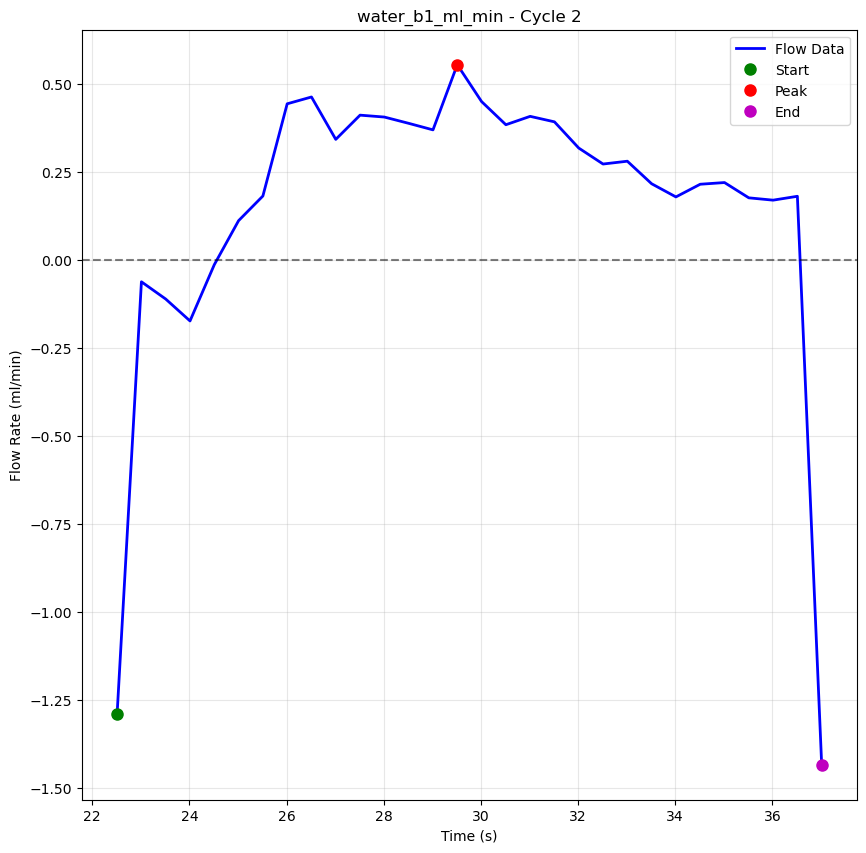

In [218]:
# Simple example: Get and plot a single cycle
sample_name = 'water_b1_ml_min'
#sample_name = 'si350_t2_ml_min'
cycle_number = 2

# Get cycle data
cycle_data = get_cycle_data(sample_name, cycle_number)

# Plot the cycle
plt.figure(figsize=(10, 10))
plt.plot(cycle_data['cycle_time'], cycle_data['cycle_flow'], 'b-', linewidth=2, label='Flow Data')
   
# Mark start, peak, and end points
plt.plot(cycle_data['start_time'], cycle_data['start_flow'], 'go', markersize=8, label='Start')
plt.plot(cycle_data['peak_time'], cycle_data['peak_flow'], 'ro', markersize=8, label='Peak')
plt.plot(cycle_data['end_time'], cycle_data['end_flow'], 'mo', markersize=8, label='End')
  
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Flow Rate (ml/min)')
plt.title(f'{sample_name} - Cycle {cycle_number}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [255]:
from scipy.signal import savgol_filter
from scipy.stats import linregress

def apply_savitzky_filter(cycle_data, window_length=5, polyorder=3):
    """
    Apply Savitzky-Golay filter to smooth cycle data and identify segment boundaries.
    
    Parameters:
    - cycle_data: dict from get_cycle_data() containing cycle information
    - window_length: int, window length for Savitzky-Golay filter (must be odd)
    - polyorder: int, polynomial order for Savitzky-Golay filter
    
    Returns:
    - dict with smoothed data and segment boundaries
    """
    if cycle_data is None:
        print("No cycle data provided")
        return None
    
    # Extract cycle time and flow data
    time_orig = cycle_data['cycle_time']
    flow_orig = cycle_data['cycle_flow']
    
    if len(time_orig) < window_length:
        print(f"Insufficient data points ({len(time_orig)}) for filtering (need >= {window_length})")
        return None
    
    # Apply Savitzky-Golay filter to smooth the data
    flow_smooth = savgol_filter(flow_orig, window_length, polyorder)
    
    # Calculate derivatives to identify change points
    dt = np.diff(time_orig)
    dy_smooth = np.diff(flow_smooth)
    slope = dy_smooth / np.maximum(dt, 1e-12)
    
    # Smooth the slope as well for better change point detection
    if len(slope) >= window_length:
        slope_smooth = savgol_filter(slope, window_length, polyorder)
    else:
        slope_smooth = slope
    
    # Find critical points for 4-line segmentation based on revised specifications
    n_points = len(time_orig)
    
    # Define temporal boundaries for constraints
    quarter_point = n_points // 4          # 25% of cycle
    three_quarter_point = 3 * n_points // 4  # 75% of cycle
    
    # B2: Find the peak (maximum flow) between 25% and 75% of cycle
    # Search for peak in the middle 50% of the cycle
    peak_search_start = quarter_point
    peak_search_end = three_quarter_point
    
    if peak_search_end <= peak_search_start:
        # Fallback if data is too short
        peak_search_start = max(1, n_points // 3)
        peak_search_end = min(n_points - 2, 2 * n_points // 3)
    
    # Find peak (maximum) in smoothed flow data
    peak_region_flow = flow_smooth[peak_search_start:peak_search_end]
    if len(peak_region_flow) > 0:
        peak_local_idx = np.argmax(peak_region_flow)
        seg2_end = peak_search_start + peak_local_idx  # B2 = peak
    else:
        seg2_end = n_points // 2  # Fallback to middle
    
    # B1: Find where gradient loses its huge value (before 25% of cycle)
    # Look for significant decrease in slope magnitude in first quarter
    def find_gradient_loss(search_end_idx, slope_data):
        """Find where gradient loses its huge initial value"""
        if search_end_idx < 3:
            return search_end_idx // 2
        
        # Calculate slope magnitude (absolute value)
        slope_magnitude = np.abs(slope_data[:search_end_idx-1])
        
        if len(slope_magnitude) < 3:
            return search_end_idx // 2
        
        # Find where slope magnitude drops significantly from its initial high value
        # Look for the point where slope drops to 50% of initial maximum
        initial_max_slope = np.max(slope_magnitude[:min(3, len(slope_magnitude))])
        threshold = initial_max_slope * 0.5
        
        # Find first point where slope drops below threshold
        drop_indices = np.where(slope_magnitude < threshold)[0]
        if len(drop_indices) > 0:
            return min(drop_indices[0] + 1, search_end_idx - 1)
        else:
            # If no significant drop found, use 1/3 of the search region
            return max(1, search_end_idx // 3)
    
    seg1_end = find_gradient_loss(quarter_point, slope_smooth)
    
    # B3: Find where gradient changes significantly (after 75% of cycle)
    # Look for significant change in gradient value in last quarter
    def find_gradient_change(search_start_idx, slope_data):
        """Find where gradient value changes significantly in the final phase"""
        if search_start_idx >= len(slope_data) - 2:
            return len(slope_data) - 1
        
        # Get slope values in the last quarter
        slope_segment = slope_data[search_start_idx:]
        
        if len(slope_segment) < 3:
            return min(search_start_idx + 1, len(slope_data) - 1)
        
        # Calculate gradient changes (second derivative)
        gradient_changes = np.abs(np.diff(slope_segment))
        
        if len(gradient_changes) == 0:
            return search_start_idx + len(slope_segment) // 2
        
        # Find the point with maximum gradient change
        max_change_idx = np.argmax(gradient_changes)
        
        # Also check for threshold-based detection
        # Use median of gradient changes as baseline
        change_threshold = np.median(gradient_changes) * 2.0
        
        # Find first significant change above threshold
        significant_changes = np.where(gradient_changes > change_threshold)[0]
        
        if len(significant_changes) > 0:
            # Use the first significant change, but prefer it to be closer to max change
            first_sig_change = significant_changes[0]
            # If max change is within 3 points of first significant change, use max
            if abs(max_change_idx - first_sig_change) <= 3:
                return search_start_idx + max_change_idx + 1
            else:
                return search_start_idx + first_sig_change + 1
        else:
            # If no threshold crossings, use maximum change point
            return search_start_idx + max_change_idx + 1
    
    seg3_end = find_gradient_change(three_quarter_point, slope_smooth)
    
    # Ensure boundaries are in order and valid with revised constraints
    # B1 must be in first 25% of cycle
    seg1_end = max(1, min(seg1_end, quarter_point))
    
    # B2 (peak) must be between B1 and 75% of cycle, and after 25%  
    seg2_end = max(seg1_end + 1, min(seg2_end, three_quarter_point))
    seg2_end = max(quarter_point, seg2_end)  # Ensure B2 is after first 25%
    
    # B3 must be after 75% of cycle and after B2
    seg3_end = max(seg2_end + 1, min(seg3_end, n_points - 1))
    seg3_end = max(three_quarter_point, seg3_end)  # Ensure B3 is after last 25%
    
    # Define segment boundaries with revised specifications:
    # B1: Where gradient loses huge value (< 25% of cycle)
    # B2: Peak of cycle (between 25% and 75% of cycle) 
    # B3: Where gradient value changes significantly (> 75% of cycle)
    boundaries = {
        'seg1_end': seg1_end,    # B1: End of sharp increase phase
        'seg2_end': seg2_end,    # B2: Peak (end of gradual increase phase)
        'seg3_end': seg3_end,    # B3: Where gradient changes significantly 
        'n_points': n_points
    }
    
    return {
        'time_orig': time_orig,
        'flow_orig': flow_orig,
        'flow_smooth': flow_smooth,
        'boundaries': boundaries,
        'smoothing_params': {
            'window_length': window_length,
            'polyorder': polyorder
        },
        'cycle_data': cycle_data
    }

def fit_segments_to_cycle(filtered_data, plot=True):
    """
    Fit polynomial segments to cycle data with different orders for each segment:
    1. Sharp increase: 1st order (linear)
    2. Gradual increase: 2nd order (quadratic, concave down)  
    3. Gradual decrease: 2nd order (quadratic, concave up)
    4. Sharp decrease: 1st order (linear)
    
    Parameters:
    - filtered_data: dict from apply_savitzky_filter() containing smoothed data
    - plot: bool, whether to create visualization
    
    Returns:
    - dict with fitted segments and statistics
    """
    if filtered_data is None:
        print("No filtered data provided")
        return None
    
    time_orig = filtered_data['time_orig']
    flow_orig = filtered_data['flow_orig']
    flow_smooth = filtered_data['flow_smooth']
    boundaries = filtered_data['boundaries']
    
    seg1_end = boundaries['seg1_end']
    seg2_end = boundaries['seg2_end']
    seg3_end = boundaries['seg3_end']
    n_points = boundaries['n_points']
    
    # Define the 4 segments with their polynomial orders
    segments = {
        'line1': {  # Sharp increase - 1st order (linear)
            'start_idx': 0,
            'end_idx': seg1_end,
            'name': 'Sharp Increase',
            'color': 'red',
            'poly_order': 1
        },
        'line2': {  # Gradual increase - 2nd order (quadratic)
            'start_idx': seg1_end,
            'end_idx': seg2_end,
            'name': 'Gradual Increase', 
            'color': 'orange',
            'poly_order': 2
        },
        'line3': {  # Gradual decrease - 2nd order (quadratic)
            'start_idx': seg2_end,
            'end_idx': seg3_end,
            'name': 'Gradual Decrease',
            'color': 'green',
            'poly_order': 2
        },
        'line4': {  # Sharp decrease - 1st order (linear)
            'start_idx': seg3_end,
            'end_idx': n_points - 1,
            'name': 'Sharp Decrease',
            'color': 'purple',
            'poly_order': 1
        }
    }
    
    # Fit polynomials to each segment
    for line_name, seg in segments.items():
        start_idx = seg['start_idx']
        end_idx = seg['end_idx']
        poly_order = seg['poly_order']
        
        if end_idx <= start_idx:
            continue
            
        # Get segment data
        t_seg = time_orig[start_idx:end_idx+1]
        y_seg = flow_smooth[start_idx:end_idx+1]  # Use smoothed data for fitting
        
        if len(t_seg) >= poly_order + 1:  # Need at least poly_order+1 points
            # Polynomial fitting with concavity constraints for quadratic segments
            if poly_order == 2:
                # For quadratic segments, ensure proper concavity
                poly_coeffs = np.polyfit(t_seg, y_seg, poly_order)
                
                # Check and enforce concavity constraints
                if line_name == 'line2':  # Gradual increase - should be concave down
                    if poly_coeffs[0] > 0:  # If concave up, force concave down
                        poly_coeffs[0] = -abs(poly_coeffs[0]) * 0.1  # Small negative curvature
                elif line_name == 'line3':  # Gradual decrease - should be concave up
                    if poly_coeffs[0] < 0:  # If concave down, force concave up
                        poly_coeffs[0] = abs(poly_coeffs[0]) * 0.1   # Small positive curvature
                        
                poly_func = np.poly1d(poly_coeffs)
            else:
                # Standard polynomial fitting for linear segments
                poly_coeffs = np.polyfit(t_seg, y_seg, poly_order)
                poly_func = np.poly1d(poly_coeffs)
            
            # Calculate R-squared
            y_pred = poly_func(t_seg)
            ss_res = np.sum((y_seg - y_pred) ** 2)
            ss_tot = np.sum((y_seg - np.mean(y_seg)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            # For linear segments, also calculate slope
            if poly_order == 1:
                slope_val = poly_coeffs[0]  # First coefficient is slope
                intercept = poly_coeffs[1]   # Second coefficient is intercept
            else:
                # For cubic segments, calculate average slope
                slope_val = (y_seg[-1] - y_seg[0]) / (t_seg[-1] - t_seg[0]) if len(t_seg) > 1 else 0
                intercept = np.nan
            
            # Store segment information
            seg.update({
                'start_time': time_orig[start_idx],
                'end_time': time_orig[end_idx],
                'start_flow': flow_orig[start_idx],
                'end_flow': flow_orig[end_idx],
                'start_flow_smooth': flow_smooth[start_idx],
                'end_flow_smooth': flow_smooth[end_idx],
                'poly_coeffs': poly_coeffs,
                'poly_func': poly_func,
                'slope': slope_val,
                'intercept': intercept,
                'r_squared': r_squared,
                'duration': time_orig[end_idx] - time_orig[start_idx],
                'data_points': end_idx - start_idx + 1
            })
        else:
            # Handle degenerate case
            seg.update({
                'start_time': time_orig[start_idx],
                'end_time': time_orig[end_idx] if end_idx < len(time_orig) else time_orig[start_idx],
                'start_flow': flow_orig[start_idx],
                'end_flow': flow_orig[end_idx] if end_idx < len(flow_orig) else flow_orig[start_idx],
                'poly_coeffs': [0],
                'poly_func': None,
                'slope': 0,
                'intercept': flow_orig[start_idx],
                'r_squared': 0,
                'duration': 0,
                'data_points': 1
            })
    
    # Create visualization if requested
    if plot:
        plt.figure(figsize=(14, 10))
        
        # Plot original data
        plt.plot(time_orig, flow_orig, 'b-', alpha=0.6, linewidth=1, label='Original Data')
        
        # Plot smoothed data
        plt.plot(time_orig, flow_smooth, 'k-', linewidth=2, label='Savitzky-Golay Smoothed')
        
        # Plot each fitted segment
        for line_name, seg in segments.items():
            if 'poly_func' in seg and seg['poly_func'] is not None:
                start_idx = seg['start_idx']
                end_idx = seg['end_idx']
                t_seg = time_orig[start_idx:end_idx+1]
                
                # Generate smooth curve for plotting
                t_plot = np.linspace(t_seg[0], t_seg[-1], 100)
                y_plot = seg['poly_func'](t_plot)
                
                if seg['poly_order'] == 1:
                    order_text = f"({seg['poly_order']}st order)"
                elif seg['poly_order'] == 2:
                    concavity = "concave down" if line_name == 'line2' else "concave up" if line_name == 'line3' else ""
                    order_text = f"({seg['poly_order']}nd order, {concavity})"
                else:
                    order_text = f"({seg['poly_order']}rd order)"
                plt.plot(t_plot, y_plot, color=seg['color'], linewidth=3, 
                        label=f"{seg['name']} {order_text} (R²={seg['r_squared']:.3f})")
        
        # Mark segment boundaries
        boundary_times = [segments['line1']['end_time'], 
                         segments['line2']['end_time'], 
                         segments['line3']['end_time']]
        for i, t_boundary in enumerate(boundary_times):
            plt.axvline(x=t_boundary, color='gray', linestyle='--', alpha=0.7)
            plt.text(t_boundary, plt.ylim()[1] * 0.9, f'B{i+1}', 
                    ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
        plt.xlabel('Time (s)')
        plt.ylabel('Flow Rate (ml/min)')
        
        # Get smoothing parameters for title
        smooth_params = filtered_data['smoothing_params']
        plt.title(f'4-Line Cycle Simulation with Mixed Polynomial Orders\n'
                 f'Savitzky-Golay Filter (window={smooth_params["window_length"]}, order={smooth_params["polyorder"]})\n'
                 f'Linear: Segments 1&4, Quadratic: Segments 2&3 (concave down/up)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Calculate overall statistics
    cycle_data = filtered_data['cycle_data']
    total_duration = cycle_data['duration']
    line_durations = [seg['duration'] for seg in segments.values() if 'duration' in seg]
    line_slopes = [seg['slope'] for seg in segments.values() if 'slope' in seg and not np.isnan(seg['slope'])]
    line_r_squared = [seg['r_squared'] for seg in segments.values() if 'r_squared' in seg]
    
    result = {
        'segments': segments,
        'filtered_data': filtered_data,
        'statistics': {
            'total_duration': total_duration,
            'line_durations': line_durations,
            'line_slopes': line_slopes,
            'mean_r_squared': np.mean(line_r_squared) if line_r_squared else 0,
            'slope_range': np.max(line_slopes) - np.min(line_slopes) if line_slopes else 0
        },
        'cycle_info': cycle_data
    }
    
    return result

Analyzing water_b2_ml_min, cycle 6
✓ Cycle data retrieved: 30 data points
  Duration: 14.51 seconds
  Flow range: -1.1556 to 0.5008 ml/min

🔧 Applying Savitzky-Golay filtering...
✓ Filtering completed
  Segment boundaries: 2, 14, 28

📊 Fitting polynomial segments...


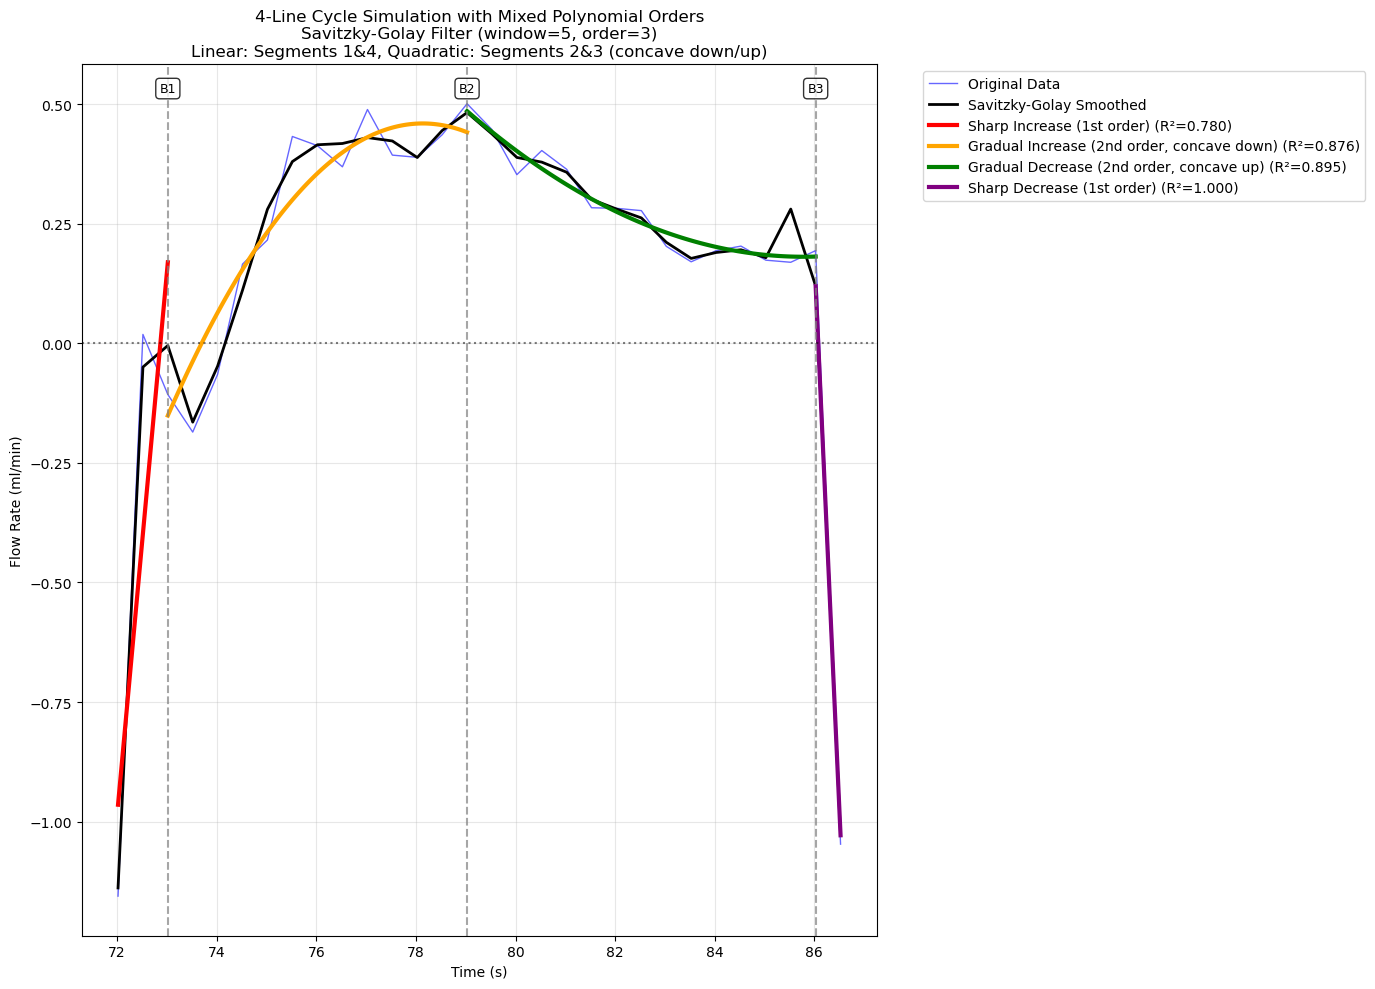

✓ Segment fitting completed

SIMULATION RESULTS

Sharp Increase (1st order polynomial):
  Time: 72.02 → 73.02 s (duration: 1.00s)
  Flow: -1.1556 → -0.1070 ml/min
  Slope: 1.1339 ml/min/s
  R²: 0.7797
  Data points: 3

Gradual Increase (2rd order polynomial):
  Time: 73.02 → 79.03 s (duration: 6.01s)
  Flow: -0.1070 → 0.5008 ml/min
  Slope: 0.0810 ml/min/s
  R²: 0.8764
  Data points: 13

Gradual Decrease (2rd order polynomial):
  Time: 79.03 → 86.03 s (duration: 7.00s)
  Flow: 0.5008 → 0.1938 ml/min
  Slope: -0.0518 ml/min/s
  R²: 0.8949
  Data points: 15

Sharp Decrease (1st order polynomial):
  Time: 86.03 → 86.53 s (duration: 0.50s)
  Flow: 0.1938 → -1.0470 ml/min
  Slope: -2.2962 ml/min/s
  R²: 1.0000
  Data points: 2

Overall Statistics:
  Mean R²: 0.8878
  Slope range: 3.4301 ml/min/s
  Total duration: 14.51 s
  Line durations: ['1.00s', '6.01s', '7.00s', '0.50s']

🎯 Analysis complete!


In [256]:
# Example: Analyze a single cycle with the two new functions

# Select a sample and cycle to analyze
sample_name = 'water_b2_ml_min'
cycle_number = 6

print(f"Analyzing {sample_name}, cycle {cycle_number}")
print("="*50)

# Step 1: Get cycle data
cycle_data = get_cycle_data(sample_name, cycle_number)

if cycle_data is None:
    print("Could not retrieve cycle data")
else:
    print(f"✓ Cycle data retrieved: {len(cycle_data['cycle_time'])} data points")
    print(f"  Duration: {cycle_data['duration']:.2f} seconds")
    print(f"  Flow range: {min(cycle_data['cycle_flow']):.4f} to {max(cycle_data['cycle_flow']):.4f} ml/min")
    
    # Step 2: Apply Savitzky-Golay filtering 
    print("\n🔧 Applying Savitzky-Golay filtering...")
    filtered_data = apply_savitzky_filter(cycle_data, window_length=5, polyorder=3)
    
    if filtered_data is None:
        print("Filtering failed")
    else:
        print("✓ Filtering completed")
        boundaries = filtered_data['boundaries']
        print(f"  Segment boundaries: {boundaries['seg1_end']}, {boundaries['seg2_end']}, {boundaries['seg3_end']}")
        
        # Step 3: Fit polynomial segments
        print("\n📊 Fitting polynomial segments...")
        simulation_result = fit_segments_to_cycle(filtered_data, plot=True)
        
        if simulation_result is None:
            print("Segment fitting failed")
        else:
            print("✓ Segment fitting completed")
            print("\n" + "="*60)
            print("SIMULATION RESULTS")
            print("="*60)
            
            # Display detailed results for each segment
            for line_name, seg in simulation_result['segments'].items():
                print(f"\n{seg['name']} ({seg['poly_order']}{'st' if seg['poly_order']==1 else 'rd'} order polynomial):")
                print(f"  Time: {seg['start_time']:.2f} → {seg['end_time']:.2f} s (duration: {seg['duration']:.2f}s)")
                print(f"  Flow: {seg['start_flow']:.4f} → {seg['end_flow']:.4f} ml/min")
                print(f"  Slope: {seg['slope']:.4f} ml/min/s")
                print(f"  R²: {seg['r_squared']:.4f}")
                print(f"  Data points: {seg['data_points']}")
            
            # Display overall statistics
            print(f"\nOverall Statistics:")
            stats = simulation_result['statistics']
            print(f"  Mean R²: {stats['mean_r_squared']:.4f}")
            print(f"  Slope range: {stats['slope_range']:.4f} ml/min/s")
            print(f"  Total duration: {stats['total_duration']:.2f} s")
            print(f"  Line durations: {[f'{d:.2f}s' for d in stats['line_durations']]}")
            
            print("\n🎯 Analysis complete!")

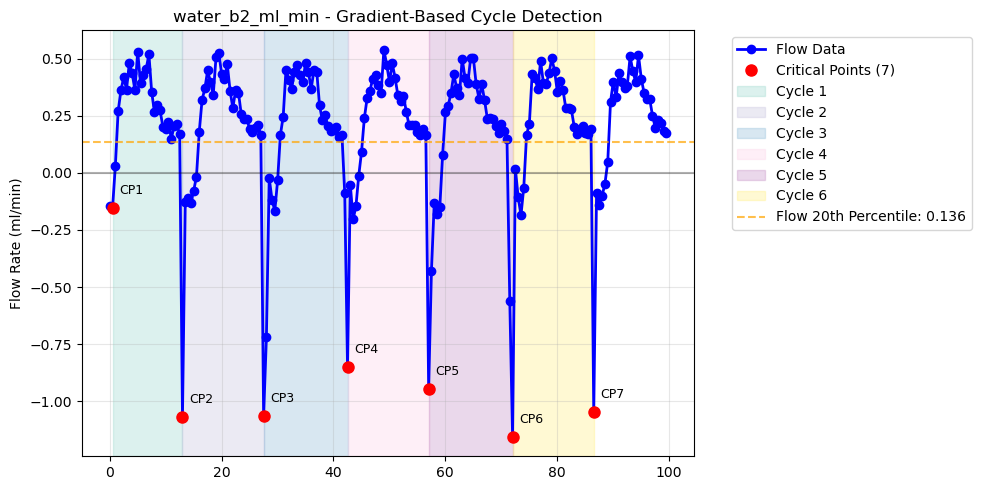

In [192]:
# Test the revised gradient-based find_flow_cycles function

def visualize_gradient_analysis(sample_column, time_range=None, df=df):
    """
    Visualize the gradient analysis process for a given sample.
    
    Parameters:
    - sample_column: string, column name to analyze
    - time_range: tuple (start_time, end_time) to focus on specific time window
    - df: DataFrame containing the data
    """
    time_data = df['time_s'].values
    flow_data = df[sample_column].values
    
    # Apply time range filter if specified
    if time_range:
        mask = (time_data >= time_range[0]) & (time_data <= time_range[1])
        time_data = time_data[mask]
        flow_data = flow_data[mask]
    
    # Remove NaN values
    valid_mask = ~np.isnan(flow_data)
    valid_time = time_data[valid_mask]
    valid_flow = flow_data[valid_mask]
    
    if len(valid_flow) < 10:
        print(f"Insufficient data for {sample_column}")
        return
    
    # Calculate gradients and 20th percentile of flow for display purposes
    gradients = np.diff(valid_flow)
    flow_20th_percentile = np.percentile(valid_flow, 20)
    
    # Get cycles and critical points using the actual find_flow_cycles function
    cycles = find_flow_cycles(time_data, flow_data, min_distance_sec=1.0)
    
    # Extract critical points information from the cycles
    critical_points = []
    if cycles:
        # Add first critical point (start of first cycle)
        first_cycle = cycles[0]
        critical_points.append({
            'time': first_cycle['start_time'],
            'flow': first_cycle['start_flow'],
            'flow_threshold': first_cycle['flow_threshold']
        })
        
        # Add all subsequent critical points (end of each cycle = start of next cycle)
        for cycle in cycles:
            critical_points.append({
                'time': cycle['end_time'],
                'flow': cycle['end_flow'],
                'flow_threshold': cycle['flow_threshold']
            })
    
    # Create visualization
    plt.figure(figsize=(10, 5))
    
    # Plot 1: Original flow data with critical points and cycles
    plt.plot(valid_time, valid_flow, 'b-', marker = 'o', linewidth=2, label='Flow Data')
    
    # Mark critical points
    if critical_points:
        cp_times = [cp['time'] for cp in critical_points]
        cp_flows = [cp['flow'] for cp in critical_points]
        plt.plot(cp_times, cp_flows, 'ro', markersize=8, label=f'Critical Points ({len(critical_points)})')
        
        # Annotate critical points
        for i, cp in enumerate(critical_points):
            plt.annotate(f'CP{i+1}', (cp['time'], cp['flow']), 
                           xytext=(5, 10), textcoords='offset points', fontsize=9)
    
    # Mark cycles
    colors = plt.cm.Set3(np.linspace(0, 1, max(len(cycles), 1)))
    for i, cycle in enumerate(cycles):
        plt.axvspan(cycle['start_time'], cycle['end_time'], 
                       alpha=0.3, color=colors[i], label=f'Cycle {i+1}')
    
    plt.axhline(y=flow_20th_percentile, color='orange', linestyle='--', alpha=0.7, 
                    label=f'Flow 20th Percentile: {flow_20th_percentile:.3f}')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.ylabel('Flow Rate (ml/min)')
    plt.title(f'{sample_column} - Gradient-Based Cycle Detection')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
        
    return cycles, critical_points

# Test with a water sample
#test_sample = 'si350_t1_ml_min'
test_sample = 'water_b2_ml_min'
cycles, cps = visualize_gradient_analysis(test_sample, time_range=(0, 100))

In [194]:
def plot_individual_cycle(sample_column, cycle_number, df=df, time=None, ax=None):
    """
    Plot a specific cycle for a given sample.
    
    Parameters:
    - sample_column: string, column name in DataFrame
    - cycle_number: int, cycle number to plot (1-indexed)
    - df: DataFrame containing the data
    - time: time array (if None, uses df['time_s'])
    - ax: matplotlib axes object (if None, creates new figure)
    
    Returns:
    - ax: matplotlib axes object
    """
    cycle_data = get_cycle_data(sample_column, cycle_number, df, time)
    
    if cycle_data is None:
        return None
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plot the cycle data
    ax.plot(cycle_data['cycle_time'], cycle_data['cycle_flow'], 'b-', linewidth=2, label='Flow Data')
    
    # Mark start, peak, and end points
    ax.plot(cycle_data['start_time'], cycle_data['start_flow'], 'go', markersize=8, label='Start')
    ax.plot(cycle_data['peak_time'], cycle_data['peak_flow'], 'ro', markersize=8, label='Peak')
    ax.plot(cycle_data['end_time'], cycle_data['end_flow'], 'mo', markersize=8, label='End')
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Formatting
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Flow Rate (ml/min)')
    ax.set_title(f'{sample_column} - Cycle {cycle_number}\n'
                f'Duration: {cycle_data["duration"]:.2f}s, Peak: {cycle_data["peak_flow"]:.4f} ml/min')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

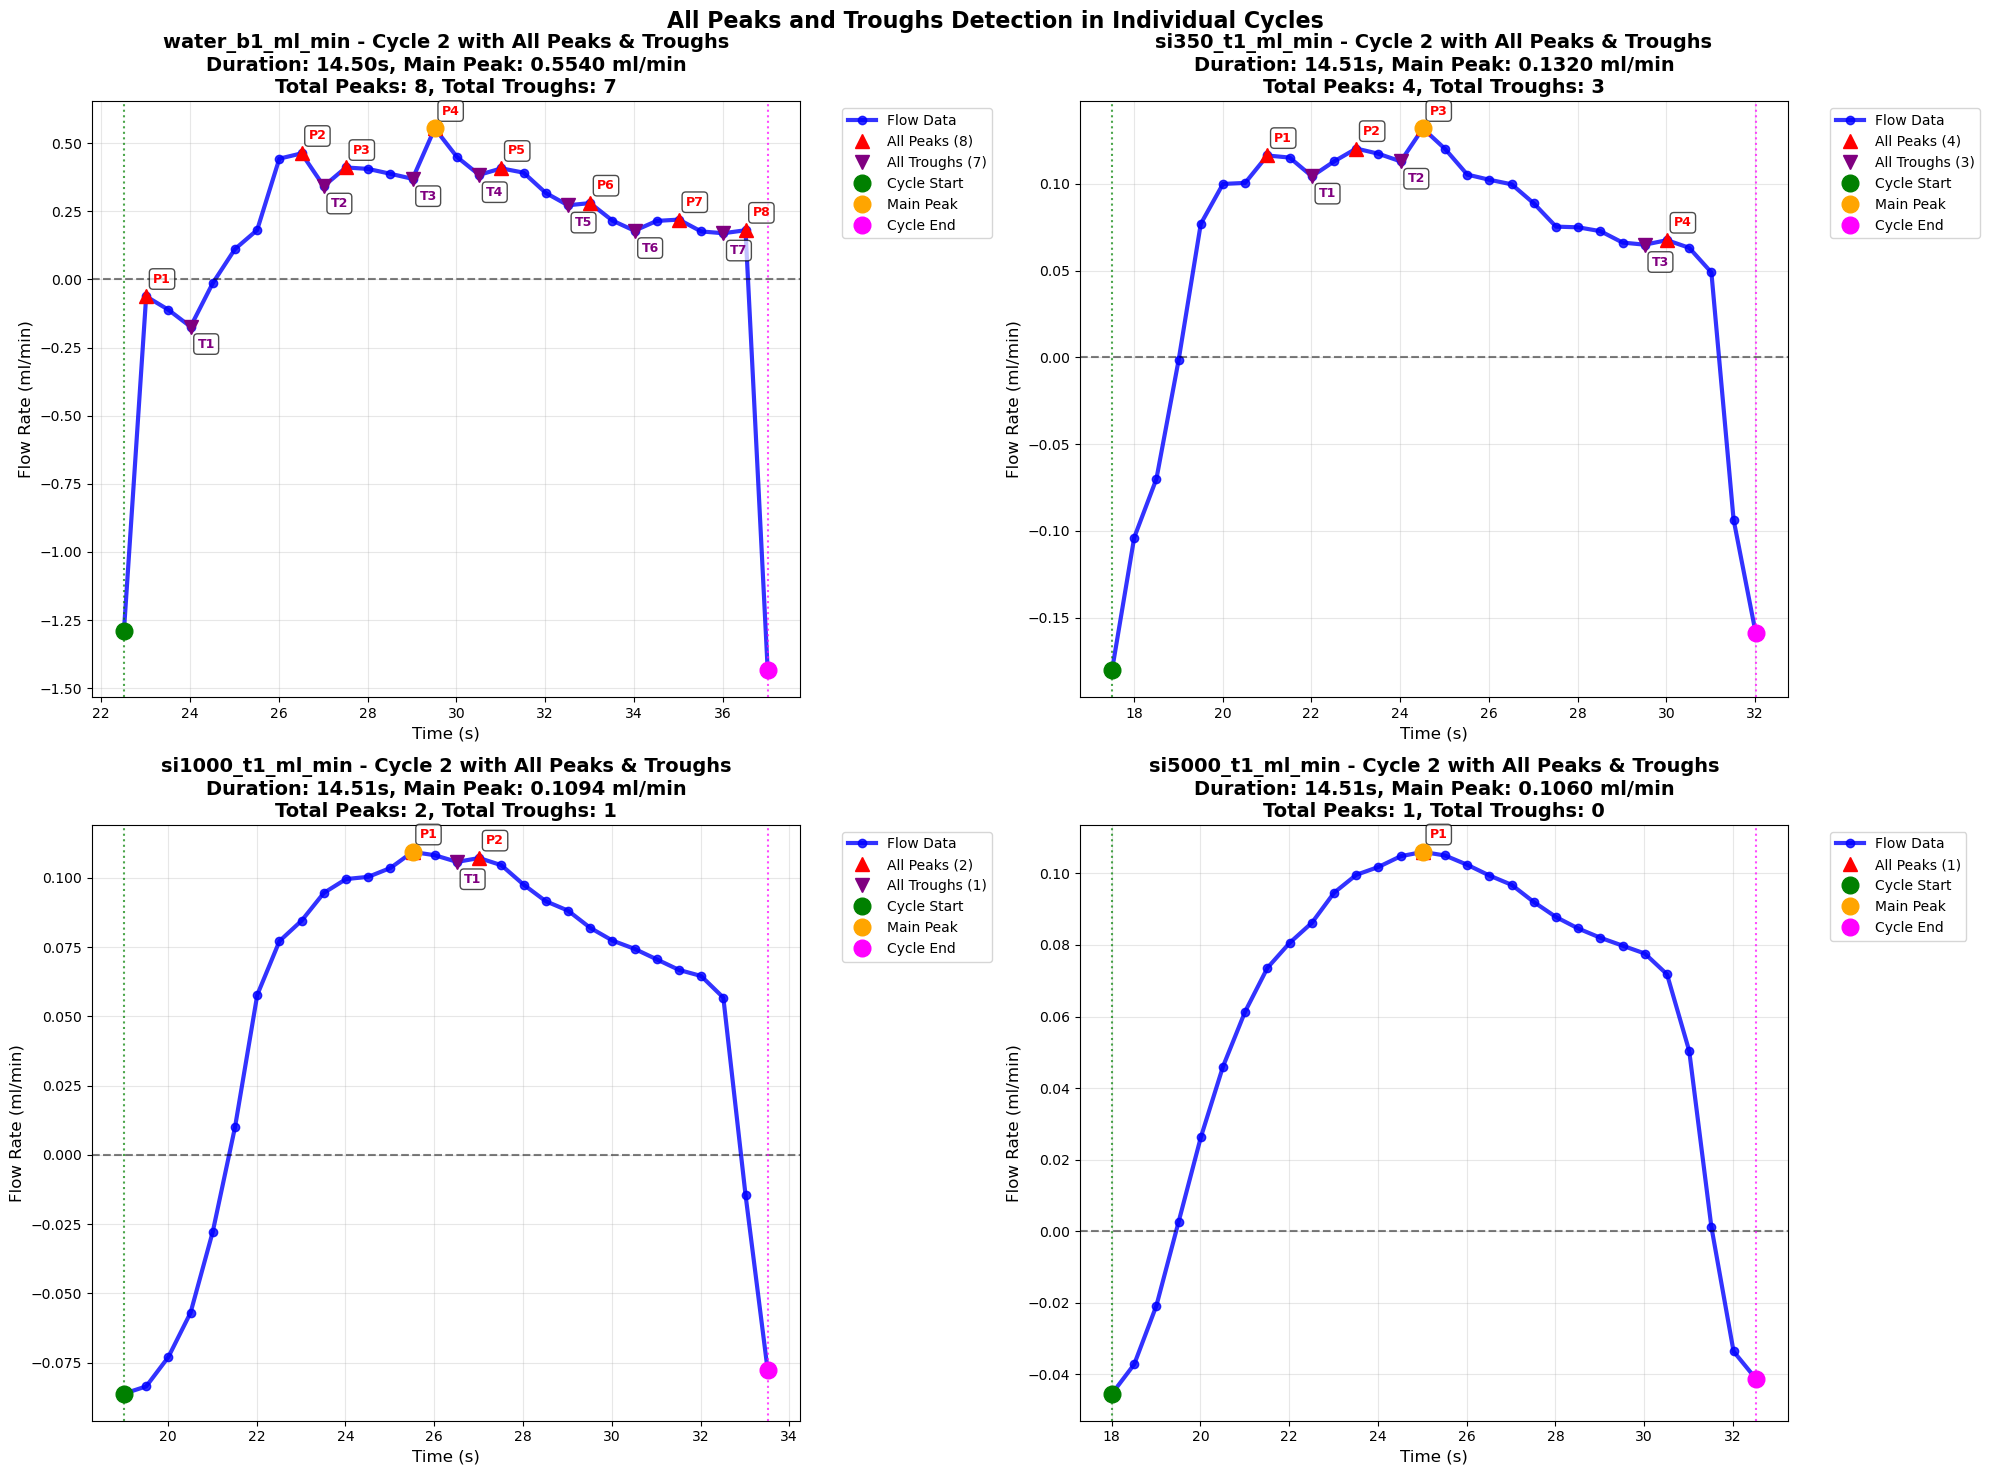

Detailed Peak/Trough Analysis:
Sample: water_b1_ml_min, Cycle: 2
Cycle duration: 14.50 seconds
Data points in cycle: 30

All Peaks detected:
  Peak 1: t=23.013s, flow=-0.0624 ml/min
  Peak 2: t=26.513s, flow=0.4624 ml/min
  Peak 3: t=27.513s, flow=0.4108 ml/min
  Peak 4: t=29.514s, flow=0.5540 ml/min
  Peak 5: t=31.014s, flow=0.4074 ml/min
  Peak 6: t=33.014s, flow=0.2800 ml/min
  Peak 7: t=35.014s, flow=0.2194 ml/min
  Peak 8: t=36.514s, flow=0.1804 ml/min

All Troughs detected:
  Trough 1: t=24.013s, flow=-0.1736 ml/min
  Trough 2: t=27.013s, flow=0.3420 ml/min
  Trough 3: t=29.014s, flow=0.3690 ml/min
  Trough 4: t=30.514s, flow=0.3836 ml/min
  Trough 5: t=32.514s, flow=0.2720 ml/min
  Trough 6: t=34.014s, flow=0.1786 ml/min
  Trough 7: t=36.014s, flow=0.1694 ml/min

Main cycle characteristics:
  Main peak: t=29.514s, flow=0.5540 ml/min
  Cycle start: t=22.513s, flow=-1.2886 ml/min
  Cycle end: t=37.014s, flow=-1.4338 ml/min


In [196]:
def plot_cycle_with_all_peaks_troughs(sample_column, cycle_number, df=df, time=None, ax=None):
    """
    Plot a specific cycle with ALL peaks and troughs detected within that cycle.
    
    Parameters:
    - sample_column: string, column name in DataFrame
    - cycle_number: int, cycle number to plot (1-indexed)
    - df: DataFrame containing the data
    - time: time array (if None, uses df['time_s'])
    - ax: matplotlib axes object (if None, creates new figure)
    
    Returns:
    - ax: matplotlib axes object
    """
    cycle_data = get_cycle_data(sample_column, cycle_number, df, time)
    
    if cycle_data is None:
        return None
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Get cycle time and flow data
    cycle_time = cycle_data['cycle_time']
    cycle_flow = cycle_data['cycle_flow']
    
    # Plot the cycle data
    ax.plot(cycle_time, cycle_flow, 'b-', marker='o', linewidth=3, label='Flow Data', alpha=0.8)
    
    # Find ALL peaks and troughs within this cycle (not filtered)
    all_peaks, peak_properties = signal.find_peaks(cycle_flow, prominence=0.001)
    all_troughs, trough_properties = signal.find_peaks(-cycle_flow, prominence=0.001)
    
    # Mark ALL peaks and troughs
    if len(all_peaks) > 0:
        ax.plot(cycle_time[all_peaks], cycle_flow[all_peaks], '^', 
                color='red', markersize=10, label=f'All Peaks ({len(all_peaks)})', zorder=5)
        
        # Annotate each peak with its index
        for i, peak_idx in enumerate(all_peaks):
            ax.annotate(f'P{i+1}', 
                       (cycle_time[peak_idx], cycle_flow[peak_idx]), 
                       xytext=(5, 10), textcoords='offset points', 
                       fontsize=9, fontweight='bold', color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    if len(all_troughs) > 0:
        ax.plot(cycle_time[all_troughs], cycle_flow[all_troughs], 'v', 
                color='purple', markersize=10, label=f'All Troughs ({len(all_troughs)})', zorder=5)
        
        # Annotate each trough with its index
        for i, trough_idx in enumerate(all_troughs):
            ax.annotate(f'T{i+1}', 
                       (cycle_time[trough_idx], cycle_flow[trough_idx]), 
                       xytext=(5, -15), textcoords='offset points', 
                       fontsize=9, fontweight='bold', color='purple',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    # Mark the main cycle boundaries (start, peak, end from cycle detection)
    ax.plot(cycle_data['start_time'], cycle_data['start_flow'], 'o', 
            color='green', markersize=12, label='Cycle Start', zorder=6)
    ax.plot(cycle_data['peak_time'], cycle_data['peak_flow'], 'o', 
            color='orange', markersize=12, label='Main Peak', zorder=6)
    ax.plot(cycle_data['end_time'], cycle_data['end_flow'], 'o', 
            color='magenta', markersize=12, label='Cycle End', zorder=6)
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Add vertical lines at cycle boundaries
    ax.axvline(x=cycle_data['start_time'], color='green', linestyle=':', alpha=0.7)
    ax.axvline(x=cycle_data['end_time'], color='magenta', linestyle=':', alpha=0.7)
    
    # Formatting
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Flow Rate (ml/min)', fontsize=12)
    ax.set_title(f'{sample_column} - Cycle {cycle_number} with All Peaks & Troughs\n'
                f'Duration: {cycle_data["duration"]:.2f}s, Main Peak: {cycle_data["peak_flow"]:.4f} ml/min\n'
                f'Total Peaks: {len(all_peaks)}, Total Troughs: {len(all_troughs)}', 
                fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    return ax

# Demonstrate the function with examples from different viscosity samples
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Plot cycles from different samples to show peak/trough patterns
samples_to_analyze = [
    ('water_b1_ml_min', 2),
    ('si350_t1_ml_min', 2),
    ('si1000_t1_ml_min', 2),
    ('si5000_t1_ml_min', 2)
]

for idx, (sample, cycle_num) in enumerate(samples_to_analyze):
    row = idx // 2
    col = idx % 2
    plot_cycle_with_all_peaks_troughs(sample, cycle_num, ax=axes[row, col])

plt.suptitle('All Peaks and Troughs Detection in Individual Cycles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed analysis of peaks and troughs for one sample
print("Detailed Peak/Trough Analysis:")
print("=" * 60)

sample_to_analyze = 'water_b1_ml_min'
cycle_to_analyze = 2

cycle_data = get_cycle_data(sample_to_analyze, cycle_to_analyze)
if cycle_data:
    cycle_time = cycle_data['cycle_time']
    cycle_flow = cycle_data['cycle_flow']
    
    # Find all peaks and troughs
    all_peaks, _ = signal.find_peaks(cycle_flow, prominence=0.001)
    all_troughs, _ = signal.find_peaks(-cycle_flow, prominence=0.001)
    
    print(f"Sample: {sample_to_analyze}, Cycle: {cycle_to_analyze}")
    print(f"Cycle duration: {cycle_data['duration']:.2f} seconds")
    print(f"Data points in cycle: {len(cycle_time)}")
    print()
    
    print("All Peaks detected:")
    for i, peak_idx in enumerate(all_peaks):
        print(f"  Peak {i+1}: t={cycle_time[peak_idx]:.3f}s, flow={cycle_flow[peak_idx]:.4f} ml/min")
    
    print(f"\nAll Troughs detected:")
    for i, trough_idx in enumerate(all_troughs):
        print(f"  Trough {i+1}: t={cycle_time[trough_idx]:.3f}s, flow={cycle_flow[trough_idx]:.4f} ml/min")
    
    print(f"\nMain cycle characteristics:")
    print(f"  Main peak: t={cycle_data['peak_time']:.3f}s, flow={cycle_data['peak_flow']:.4f} ml/min")
    print(f"  Cycle start: t={cycle_data['start_time']:.3f}s, flow={cycle_data['start_flow']:.4f} ml/min")
    print(f"  Cycle end: t={cycle_data['end_time']:.3f}s, flow={cycle_data['end_flow']:.4f} ml/min")

## Example: Plotting individual cycles using the captured data

In [ ]:
# Demonstrate plotting individual cycles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot cycles from different samples
samples_to_plot = [
    ('water_b1_ml_min', 2),
    ('si350_t1_ml_min', 2),
    ('si1000_t1_ml_min', 3),
    ('si5000_t1_ml_min', 2)
]

for idx, (sample, cycle_num) in enumerate(samples_to_plot):
    row = idx // 2
    col = idx % 2
    plot_individual_cycle(sample, cycle_num, ax=axes[row, col])

plt.suptitle('Individual Cycle Data Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Enhanced find_flow_cycles Function Summary

The `find_flow_cycles` function has been enhanced to capture the actual recorded flow data for each detected cycle. Now each cycle dictionary includes:

### New Fields Added:
- **`cycle_time`**: NumPy array containing the time values (seconds) for this specific cycle
- **`cycle_flow`**: NumPy array containing the flow values (ml/min) for this specific cycle  
- **`data_points`**: Integer indicating the number of data points in the cycle

### Usage Examples:

#### 1. Basic cycle detection with data capture:
```python
cycles = find_flow_cycles(time_array, flow_array)
for cycle in cycles:
    time_data = cycle['cycle_time']    # Time array for this cycle
    flow_data = cycle['cycle_flow']    # Flow array for this cycle
    # Analyze individual cycle data...
```

#### 2. Get specific cycle data using convenience function:
```python
cycle_data = get_cycle_data('water_b1_ml_min', 2)  # Get cycle 2 from water sample
if cycle_data:
    time_series = cycle_data['cycle_time']
    flow_series = cycle_data['cycle_flow']
```

#### 3. Plot individual cycles:
```python
plot_individual_cycle('si1000_t1_ml_min', 1)  # Plot cycle 1 from silicon oil sample
```

### Benefits:
- **Individual cycle analysis**: Can now analyze each cycle's characteristics independently
- **High-resolution data**: Access to all original data points within each cycle
- **Flexible processing**: Apply different analysis methods to individual cycles
- **Validation**: Compare cycles within the same sample or across different samples
- **Custom modeling**: Fit models to individual cycle data rather than averaged data

## 2 - Visualize

In [ ]:
# Create visualizations for molecular descriptors
fig, axes = plt.subplots(6, 3, figsize=(18, 18))
fig.suptitle('MPP Curve for Different Liquids', fontsize=16, fontweight='bold')

# Define descriptors to plot
descriptors_to_plot = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

for i, descriptor in enumerate(descriptors_to_plot):
    row = i // 3
    col = i % 3

    # Line plot (time vs descriptor)
    sns.lineplot(
        data=df, x='time_s', y=descriptor,
        ax=axes[row, col], color="skyblue", linewidth=1, errorbar=None
    )

    # Compute 75th percentile for this subset
    q75 = df[descriptor].quantile(0.75)

    # Add straight horizontal line at 75% value
    axes[row, col].axhline(y=q75, color='red', linestyle='--', linewidth=1,
                           label=f'75th percentile: {q75:.3f}')

    # Titles and labels
    axes[row, col].set_title(f'{descriptor} Distribution')
    axes[row, col].set_xlabel('Time (sec)')
    axes[row, col].set_ylabel('Flow (ml/min)')
    axes[row, col].grid(True, alpha=0.3)
    #axes[row, col].set_ylim(-0.3, 0.2)
    axes[row, col].legend()


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3 - Cycle Detection

In [ ]:
# Extract time
time = df['time_s'].values

# Define flow columns in specific order
flow_columns = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"Total time points: {len(time)}")
print(f"Time range: {time[0]:.1f} - {time[-1]:.1f} seconds")
print(f"Flow columns to analyze: {len(flow_columns)}")
for i, col in enumerate(flow_columns, 1):
    print(f"  {i}. {col}")
print()

def filter_peaks_troughs(time, flow, peaks, troughs, min_distance=2.0):
    """
    Filter peaks and troughs based on:
    1. Percentile thresholds (peaks > 75th, troughs < 25th)
    2. Minimum time distance between consecutive peaks/troughs
    """
    # Calculate percentile thresholds
    valid_flow = flow[~np.isnan(flow)]
    if len(valid_flow) == 0:
        return np.array([]), np.array([]), np.nan, np.nan
    
    peak_threshold = np.percentile(valid_flow, 75)
    trough_threshold = np.percentile(valid_flow, 10)
    
    # Filter peaks above 75th percentile
    valid_peaks = []
    for p in peaks:
        if not np.isnan(flow[p]) and flow[p] >= peak_threshold:
            # Check distance from previously added peaks
            if len(valid_peaks) == 0 or (time[p] - time[valid_peaks[-1]]) >= min_distance:
                valid_peaks.append(p)
    
    # Filter troughs below 10th percentile
    valid_troughs = []
    for t in troughs:
        if not np.isnan(flow[t]) and flow[t] <= trough_threshold:
            # Check distance from previously added troughs
            if len(valid_troughs) == 0 or (time[t] - time[valid_troughs[-1]]) >= min_distance:
                valid_troughs.append(t)
    
    return np.array(valid_peaks), np.array(valid_troughs), peak_threshold, trough_threshold

def detect_cycles(time, flow, peaks, troughs):
    """
    Detect cycles with pattern: trough -> peak -> trough
    Handle consecutive troughs: first trough = start, first trough after peak = end
    Handle consecutive peaks: continue through them
    """
    if len(peaks) == 0 or len(troughs) == 0:
        return []
    
    # Combine and sort all critical points
    all_points = []
    for p in peaks:
        all_points.append(('peak', p, time[p], flow[p]))
    for t in troughs:
        all_points.append(('trough', t, time[t], flow[t]))
    
    all_points.sort(key=lambda x: x[1])  # Sort by index
    
    cycles = []
    i = 0
    
    while i < len(all_points):
        # Look for a trough to start a cycle
        if all_points[i][0] == 'trough':
            cycle_start_idx = all_points[i][1]
            cycle_start_time = all_points[i][2]
            
            # Skip consecutive troughs, keep the first one as start
            j = i + 1
            while j < len(all_points) and all_points[j][0] == 'trough':
                j += 1
            
            # Now we should find peak(s)
            if j < len(all_points) and all_points[j][0] == 'peak':
                # Continue through consecutive peaks
                while j < len(all_points) and all_points[j][0] == 'peak':
                    j += 1
                
                # Now look for the next trough (end of cycle)
                if j < len(all_points) and all_points[j][0] == 'trough':
                    cycle_end_idx = all_points[j][1]
                    cycle_end_time = all_points[j][2]
                    
                    cycles.append({
                        'start_time': cycle_start_time,
                        'end_time': cycle_end_time,
                        'duration': cycle_end_time - cycle_start_time,
                        'start_idx': cycle_start_idx,
                        'end_idx': cycle_end_idx
                    })
                    
                    # Move to this trough to potentially start next cycle
                    i = j
                    continue
        
        i += 1
    
    return cycles


In [ ]:
# Analyze each flow column
all_results = {}

for col in flow_columns:
    flow = df[col].values
    
    print("=" * 80)
    print(f"ANALYZING: {col}")
    print("=" * 80)
    
    # Remove NaN for peak detection
    valid_indices = ~np.isnan(flow)
    if np.sum(valid_indices) < 5:
        print("  Insufficient valid data points\n")
        continue
    
    # Find peaks (local maxima)
    peaks, _ = find_peaks(flow[valid_indices], prominence=0.01)
    # Map back to original indices
    peaks = np.where(valid_indices)[0][peaks]
    
    # Find troughs (local minima) by inverting the signal
    troughs, _ = find_peaks(-flow[valid_indices], prominence=0.01)
    troughs = np.where(valid_indices)[0][troughs]
    
    print(f"\nInitial detection:")
    print(f"  Raw peaks found: {len(peaks)}")
    print(f"  Raw troughs found: {len(troughs)}")
    
    # Filter peaks and troughs based on percentile and distance
    peaks, troughs, peak_thresh, trough_thresh = filter_peaks_troughs(time, flow, peaks, troughs, min_distance=0.0)
    
    print(f"\nAfter filtering (75th/10th percentile + min distance 2.0s):")
    print(f"  Peak threshold (75th percentile): {peak_thresh:.4f}")
    print(f"  Trough threshold (10th percentile): {trough_thresh:.4f}")
    print(f"  Valid peaks: {len(peaks)}")
    if len(peaks) > 0:
        print(f"    Times: {time[peaks]}")
        print(f"    Values: {np.round(flow[peaks], 4)}")
    
    print(f"  Valid troughs: {len(troughs)}")
    if len(troughs) > 0:
        print(f"    Times: {time[troughs]}")
        print(f"    Values: {np.round(flow[troughs], 4)}")
    
    # Detect cycles
    cycles = detect_cycles(time, flow, peaks, troughs)
    
    print(f"\n{'─' * 80}")
    print(f"CYCLES DETECTED: {len(cycles)}")
    print(f"{'─' * 80}")
    
    if cycles:
        for idx, cycle in enumerate(cycles, 1):
            print(f"Cycle {idx}:")
            print(f"  Start: {cycle['start_time']:.1f} s  |  End: {cycle['end_time']:.1f} s  |  Duration: {cycle['duration']:.2f} s")
        
        durations = [c['duration'] for c in cycles]
        print(f"\nSummary:")
        print(f"  Avg duration: {np.mean(durations):.2f} s ± {np.std(durations):.2f} s")
        print(f"  Range: [{np.min(durations):.2f}, {np.max(durations):.2f}] s")
    else:
        print("  No cycles detected")
    
    print()
    
    all_results[col] = {
        'flow': flow,
        'peaks': peaks,
        'troughs': troughs,
        'cycles': cycles,
        'peak_thresh': peak_thresh,
        'trough_thresh': trough_thresh
    }# Create visualizations for flow columns
fig, axes = plt.subplots(6, 3, figsize=(18, 18))

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, col in enumerate(flow_columns):
    if col not in all_results:
        continue
    ax = axes_flat[idx]
    result = all_results[col]
    flow = result['flow']
    peaks = result['peaks']
    troughs = result['troughs']
    cycles = result['cycles']
    peak_thresh = result['peak_thresh']
    trough_thresh = result['trough_thresh']
    
    # Plot flow rate
    ax.plot(time, flow, 'b-', linewidth=2, alpha=0.7, label='Flow Rate')
    
    # Plot threshold lines
    if not np.isnan(peak_thresh):
        ax.axhline(y=peak_thresh, color='green', linestyle=':', alpha=0.5, linewidth=1.5, label=f'75th %ile ({peak_thresh:.3f})')
    if not np.isnan(trough_thresh):
        ax.axhline(y=trough_thresh, color='red', linestyle=':', alpha=0.5, linewidth=1.5, label=f'10th %ile ({trough_thresh:.3f})')
    
    # Mark peaks and troughs
    if len(peaks) > 0:
        ax.plot(time[peaks], flow[peaks], 'g^', markersize=8, label='Peaks', zorder=5)
    if len(troughs) > 0:
        ax.plot(time[troughs], flow[troughs], 'rv', markersize=8, label='Troughs', zorder=5)
    
    # Highlight cycles
    colors = plt.cm.Set3(np.linspace(0, 1, max(len(cycles), 1)))
    for cycle_idx, cycle in enumerate(cycles):
        ax.axvspan(cycle['start_time'], cycle['end_time'], alpha=0.2, color=colors[cycle_idx])
        mid_time = (cycle['start_time'] + cycle['end_time']) / 2
        y_pos = np.nanmax(flow) * 0.85 if not np.isnan(np.nanmax(flow)) else 0.1
        ax.text(mid_time, y_pos, f"C{cycle_idx+1}", 
                ha='center', fontsize=8, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[cycle_idx], alpha=0.5))
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_ylabel('Flow Rate (ml/min)', fontsize=9)
    ax.set_title(f'{col} - {len(cycles)} cycles', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Set x-label only for bottom row
    if idx >= 10:
        ax.set_xlabel('Time (s)', fontsize=9)
plt.tight_layout()
plt.show()

# Create summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
summary_data = []
for col in all_results.keys():
    cycles = all_results[col]['cycles']
    if cycles:
        durations = [c['duration'] for c in cycles]
        summary_data.append({
            'Column': col,
            'Cycles': len(cycles),
            'Avg Duration (s)': f"{np.mean(durations):.2f}",
            'Std Dev (s)': f"{np.std(durations):.2f}",
            'Min (s)': f"{np.min(durations):.2f}",
            'Max (s)': f"{np.max(durations):.2f}"
        })
    else:
        summary_data.append({
            'Column': col,
            'Cycles': 0,
            'Avg Duration (s)': 'N/A',
            'Std Dev (s)': 'N/A',
            'Min (s)': 'N/A',
            'Max (s)': 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
summary_df

In [ ]:
def analyze_cycle_segments(time, flow, cycle_start_idx, cycle_end_idx):
    """
    Analyze a single cycle and fit 3 linear segments:
    1. Sharp increasing (first line) - from cycle start to first point that is positive AND in top 75% percentile
    2. Gradual decreasing (second line)
    3. Sharp decreasing (third line)
    """
    # Extract cycle data
    cycle_time = time[cycle_start_idx:cycle_end_idx+1]
    cycle_flow = flow[cycle_start_idx:cycle_end_idx+1]
    
    # Remove NaN values
    valid_mask = ~np.isnan(cycle_flow)
    cycle_time = cycle_time[valid_mask]
    cycle_flow = cycle_flow[valid_mask]
    
    if len(cycle_time) < 5:
        return None
    
    # Calculate 75th percentile for the cycle
    flow_75 = np.percentile(cycle_flow, 40)
    
    # Find ALL peaks and troughs within this cycle (no filtering)
    all_peaks, _ = find_peaks(cycle_flow, prominence=0.001)
    all_troughs, _ = find_peaks(-cycle_flow, prominence=0.001)
    
    # Combine all critical points
    critical_points = []
    critical_points.append((0, cycle_time[0], cycle_flow[0], 'start'))  # Start point
    
    for p in all_peaks:
        critical_points.append((p, cycle_time[p], cycle_flow[p], 'peak'))
    for t in all_troughs:
        critical_points.append((t, cycle_time[t], cycle_flow[t], 'trough'))
    
    critical_points.append((len(cycle_time)-1, cycle_time[-1], cycle_flow[-1], 'end'))  # End point
    
    # --- Detect a 'drop' critical point (start of sharp fall) ---
    # Compute local slopes (dy/dt)
    dt = np.diff(cycle_time)
    dy = np.diff(cycle_flow)
    slope = dy / np.maximum(dt, 1e-12)

    # Optional light smoothing of slope (moving average) to reduce noise
    win = 3  # set to 1 to disable smoothing
    if len(slope) >= win and win > 1:
        kernel = np.ones(win) / win
        slope_s = np.convolve(slope, kernel, mode='same')
    else:
        slope_s = slope

    # Heuristic: search for the drop *after* the local maximum of the cycle
    after_idx = int(np.argmax(cycle_flow))

    # Build a data-driven threshold for "strongly negative" slope
    neg = slope_s[slope_s < 0]
    # Use 75th percentile of |negative slopes| as a magnitude threshold
    thr_mag = np.percentile(-neg, 75) if neg.size > 0 else 0.0
    min_run = 2  # require at least this many consecutive steps below -thr_mag

    drop_k = None
    run = 0
    for k_idx in range(max(after_idx, 0), len(slope_s)):
        if slope_s[k_idx] <= -thr_mag:
            run += 1
            if run >= min_run:
                # choose the *start* of the sustained run
                drop_k = k_idx - min_run + 1
                break
        else:
            run = 0

    # Fallback: if no sustained run, use the steepest negative slope anywhere
    if drop_k is None:
        drop_k = int(np.argmin(slope_s)) if slope_s.size > 0 else None

    # Map slope index (between k and k+1) to a point index (use k+1)
    if drop_k is not None:
        cp_idx = drop_k + 1
        # keep within bounds and avoid duplicating the start/end indices
        cp_idx = int(np.clip(cp_idx, 1, len(cycle_time) - 2))
        existing_idxs = {cp[0] for cp in critical_points}
        if cp_idx not in existing_idxs:
            critical_points.append((cp_idx, cycle_time[cp_idx], cycle_flow[cp_idx], 'drop'))
    # --- end 'drop' detection ---


    # Sort by index
    critical_points.sort(key=lambda x: x[0])
    
    # Find Line 1: From cycle start to first point that is BOTH positive AND >= 75th percentile
    line1_end_idx = None
    for i, (idx, t, f, ptype) in enumerate(critical_points):
        if i == 0:  # Skip start point itself
            continue
        if f > 0 and f >= flow_75:
            line1_end_idx = idx
            line1_end_time = t
            line1_end_flow = f
            break
    
    # If no point satisfies both conditions, use the maximum point in the cycle
    if line1_end_idx is None:
        max_idx = np.argmax(cycle_flow)
        line1_end_idx = max_idx
        line1_end_time = cycle_time[max_idx]
        line1_end_flow = cycle_flow[max_idx]
    
    # Line 1: from start to the identified end point
    line1 = {
        'start_time': cycle_time[0],
        'end_time': line1_end_time,
        'start_flow': cycle_flow[0],
        'end_flow': line1_end_flow,
        'slope': (line1_end_flow - cycle_flow[0]) / (line1_end_time - cycle_time[0]) if line1_end_time != cycle_time[0] else 0,
        'start_idx': 0,
        'end_idx': line1_end_idx
    }
    
    # Calculate slopes between consecutive critical points (after Line 1 end)
    slopes = []
    for i in range(len(critical_points) - 1):
        idx1, t1, f1, _ = critical_points[i]
        idx2, t2, f2, _ = critical_points[i+1]
        
        # Only consider points after Line 1 end
        if idx1 < line1_end_idx:
            continue
        
        if t2 != t1:
            slope = (f2 - f1) / (t2 - t1)
            slopes.append({
                'segment': i,
                'start_idx': idx1,
                'end_idx': idx2,
                'start_time': t1,
                'end_time': t2,
                'start_flow': f1,
                'end_flow': f2,
                'slope': slope,
                'duration': t2 - t1
            })
    
    if len(slopes) < 2:
        # Not enough segments, create simple lines
        mid_idx = line1_end_idx + (len(cycle_time) - line1_end_idx) // 2
        
        line2 = {
            'start_time': line1_end_time,
            'end_time': cycle_time[mid_idx],
            'start_flow': line1_end_flow,
            'end_flow': cycle_flow[mid_idx],
            'slope': (cycle_flow[mid_idx] - line1_end_flow) / (cycle_time[mid_idx] - line1_end_time) if cycle_time[mid_idx] != line1_end_time else 0,
            'intercept': 0
        }
        
        line3 = {
            'segment': 0,
            'start_idx': mid_idx,
            'end_idx': len(cycle_time) - 1,
            'start_time': cycle_time[mid_idx],
            'end_time': cycle_time[-1],
            'start_flow': cycle_flow[mid_idx],
            'end_flow': cycle_flow[-1],
            'slope': (cycle_flow[-1] - cycle_flow[mid_idx]) / (cycle_time[-1] - cycle_time[mid_idx]) if cycle_time[-1] != cycle_time[mid_idx] else 0,
            'duration': cycle_time[-1] - cycle_time[mid_idx]
        }
        
        return {
            'line1': line1,
            'line2': line2,
            'line3': line3,
            'all_slopes': [],
            'critical_points': critical_points
        }
    
    # Find Line 3: steepest negative slope (sharp decrease at the end)
    negative_slopes = [s for s in slopes if s['slope'] < 0]
    
    if len(negative_slopes) > 0:
        line3 = min(negative_slopes, key=lambda x: x['slope'])
        line3_start_idx = line3['start_idx']
    else:
        line3 = slopes[-1]
        line3_start_idx = line3['start_idx']
    
    # Line 2: everything between line1 end and line3 start
    middle_segments = [s for s in slopes if s['end_idx'] <= line3_start_idx]
    
    if len(middle_segments) > 0:
        # Fit a single line through all middle points
        middle_time = []
        middle_flow = []
        for seg in middle_segments:
            start_idx = seg['start_idx']
            end_idx = seg['end_idx']
            middle_time.extend(cycle_time[start_idx:end_idx+1])
            middle_flow.extend(cycle_flow[start_idx:end_idx+1])
        
        if len(middle_time) >= 2:
            slope2, intercept2, _, _, _ = linregress(middle_time, middle_flow)
            line2 = {
                'start_time': line1_end_time,
                'end_time': cycle_time[line3_start_idx],
                'start_flow': slope2 * line1_end_time + intercept2,
                'end_flow': slope2 * cycle_time[line3_start_idx] + intercept2,
                'slope': slope2,
                'intercept': intercept2
            }
        else:
            # If only one point, create a simple connection
            line2 = {
                'start_time': line1_end_time,
                'end_time': cycle_time[line3_start_idx],
                'start_flow': line1_end_flow,
                'end_flow': cycle_flow[line3_start_idx],
                'slope': (cycle_flow[line3_start_idx] - line1_end_flow) / 
                        (cycle_time[line3_start_idx] - line1_end_time) if cycle_time[line3_start_idx] != line1_end_time else 0,
                'intercept': 0
            }
    else:
        # No middle segment, connect directly
        line2 = {
            'start_time': line1_end_time,
            'end_time': cycle_time[line3_start_idx],
            'start_flow': line1_end_flow,
            'end_flow': cycle_flow[line3_start_idx],
            'slope': (cycle_flow[line3_start_idx] - line1_end_flow) / 
                    (cycle_time[line3_start_idx] - line1_end_time) if cycle_time[line3_start_idx] != line1_end_time else 0,
            'intercept': 0
        }
    
    return {
        'line1': line1,  # Sharp increase
        'line2': line2,  # Gradual decrease
        'line3': line3,  # Sharp decrease
        'all_slopes': slopes,
        'critical_points': critical_points
    }

# Analyze each flow column
all_cycle_segments = {}

for col in flow_columns:
    if col not in df.columns:
        continue
    
    flow = df[col].values
    
    if np.all(np.isnan(flow)):
        continue
    
    print("=" * 80)
    print(f"ANALYZING: {col}")
    print("=" * 80)
    
    # Remove NaN for peak detection
    valid_indices = ~np.isnan(flow)
    if np.sum(valid_indices) < 5:
        continue
    
    # Detect cycles (using filtered peaks/troughs)
    peaks, _ = find_peaks(flow[valid_indices], prominence=0.01)
    peaks = np.where(valid_indices)[0][peaks]
    
    troughs, _ = find_peaks(-flow[valid_indices], prominence=0.01)
    troughs = np.where(valid_indices)[0][troughs]
    
    peaks_filt, troughs_filt, _, _ = filter_peaks_troughs(time, flow, peaks, troughs, min_distance=2.0)
    cycles = detect_cycles(time, flow, peaks_filt, troughs_filt)
    
    print(f"\nDetected {len(cycles)} cycles")
    
    # Analyze each cycle
    cycle_segments = []
    for cycle_num, cycle in enumerate(cycles, 1):
        print(f"\nCycle {cycle_num} (t={cycle['start_time']:.1f}s to {cycle['end_time']:.1f}s):")
        
        segments = analyze_cycle_segments(time, flow, cycle['start_idx'], cycle['end_idx'])
        
        if segments:
            print(f"  Line 1 criteria: Start at cycle beginning, end at first point that is positive AND >= 75th percentile")
            print(f"  Line 1 (Sharp Increase): slope = {segments['line1']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line1']['start_time']:.2f}s to {segments['line1']['end_time']:.2f}s")
            print(f"    Flow: {segments['line1']['start_flow']:.4f} to {segments['line1']['end_flow']:.4f} ml/min")
            print(f"  Line 2 (Gradual Change): slope = {segments['line2']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line2']['start_time']:.2f}s to {segments['line2']['end_time']:.2f}s")
            print(f"    Flow: {segments['line2']['start_flow']:.4f} to {segments['line2']['end_flow']:.4f} ml/min")
            print(f"  Line 3 (Sharp Decrease): slope = {segments['line3']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line3']['start_time']:.2f}s to {segments['line3']['end_time']:.2f}s")
            print(f"    Flow: {segments['line3']['start_flow']:.4f} to {segments['line3']['end_flow']:.4f} ml/min")
            
            cycle_segments.append({
                'cycle_num': cycle_num,
                'cycle': cycle,
                'segments': segments
            })
    
    all_cycle_segments[col] = cycle_segments

In [ ]:
# Visualize cycles with 3-line segments
fig, axes = plt.subplots(6, 3, figsize=(18, 18))
fig.suptitle('Cycle Segmentation Analysis - 3-Line Model', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, col in enumerate(flow_columns):
    if col not in all_cycle_segments:
        continue
    
    ax = axes_flat[idx]
    flow = df[col].values
    
    # Plot original data
    ax.plot(time, flow, 'b-', linewidth=1.5, alpha=0.5, label='Original Data')
    
    # Plot each cycle's segments
    cycle_data = all_cycle_segments[col]
    colors = plt.cm.tab10(np.linspace(0, 1, len(cycle_data)))
    
    for i, cycle_info in enumerate(cycle_data):
        segments = cycle_info['segments']
        color = colors[i]
        
        # Plot Line 1 (Sharp increase)
        line1 = segments['line1']
        ax.plot([line1['start_time'], line1['end_time']], 
                [line1['start_flow'], line1['end_flow']], 
                'r-', linewidth=3, alpha=0.8, label=f"C{i+1}-L1" if i == 0 else "")
        
        # Plot Line 2 (Gradual change)
        line2 = segments['line2']
        ax.plot([line2['start_time'], line2['end_time']], 
                [line2['start_flow'], line2['end_flow']], 
                'g-', linewidth=3, alpha=0.8, label=f"C{i+1}-L2" if i == 0 else "")
        
        # Plot Line 3 (Sharp decrease)
        line3 = segments['line3']
        ax.plot([line3['start_time'], line3['end_time']], 
                [line3['start_flow'], line3['end_flow']], 
                'm-', linewidth=3, alpha=0.8, label=f"C{i+1}-L3" if i == 0 else "")
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_ylabel('Flow Rate (ml/min)', fontsize=9)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if idx >= 10:
        ax.set_xlabel('Time (s)', fontsize=9)
    
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('cycle_segmentation_analysis.png', dpi=150, bbox_inches='tight')
print("\n" + "=" * 80)
print("Segmentation plot saved as 'cycle_segmentation_analysis.png'")
print("=" * 80)
plt.show()

# Export segment data
segment_export = []
for col in all_cycle_segments.keys():
    for cycle_info in all_cycle_segments[col]:
        cycle_num = cycle_info['cycle_num']
        segments = cycle_info['segments']
        
        segment_export.append({
            'Column': col,
            'Cycle': cycle_num,
            'Line1_Slope': segments['line1']['slope'],
            'Line1_Start_Time': segments['line1']['start_time'],
            'Line1_End_Time': segments['line1']['end_time'],
            'Line2_Slope': segments['line2']['slope'],
            'Line2_Start_Time': segments['line2']['start_time'],
            'Line2_End_Time': segments['line2']['end_time'],
            'Line3_Slope': segments['line3']['slope'],
            'Line3_Start_Time': segments['line3']['start_time'],
            'Line3_End_Time': segments['line3']['end_time']
        })

segment_df = pd.DataFrame(segment_export)

In [ ]:
viscosity_map = {
    'water_b1_ml_min'  : 1,
    'water_b2_ml_min'  : 1,
    'water_b3_ml_min' : 1,
    'si350_t1_ml_min' : 350,
    'si350_t2_ml_min' : 350,
    'si350_t3_ml_min' : 350,
    'si1000_t1_ml_min' : 1000,
    'si1000_t2_ml_min' : 1000,
    'si1000_t3_ml_min' : 1000,
    'si5000_t1_ml_min' : 5000,
    'si5000_t2_ml_min' : 5000,
    'si5000_t3_ml_min' : 5000,
    'si12500_t1_ml_min' : 12500,
    'si12500_t2_ml_min' : 12500,
    'si12500_t3_ml_min' : 12500
}

segment_df['Viscosity_mPa_s'] = segment_df['Column'].map(viscosity_map).astype(float)

if segment_export:
    segment_df.to_csv('cycle_segments.csv', index=False)
    print("\nSegment data exported to 'cycle_segments.csv'")
    print("=" * 80)

print(segment_df.shape)
segment_df[:60]

In [ ]:
def plot_panel_box(ax, x, y, title,
                   xlab='Viscosity (mPa·s)', ylab='Slope (ml/min/s)',
                   try_fit=True, logx=False, showfliers=False):
    # Drop NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = np.asarray(x)[mask].astype(float)
    y = np.asarray(y)[mask].astype(float)
    if x.size == 0:
        ax.set_title(title); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        return

    # Group by viscosity value (assumes viscosities like 50, 100, 200, ...)
    # If your viscosities might be non-integers, you can round: uniq = np.unique(np.round(x, 3))
    uniq = np.unique(x)
    data = [y[x == v] for v in uniq if np.sum(x == v) > 0]
    pos  = [v for v in uniq if np.sum(x == v) > 0]

    # Box plot at numeric positions corresponding to viscosity values
    bp = ax.boxplot(
        data, positions=pos, widths=0.06*(max(pos)-min(pos)) if len(pos) > 1 else 0.5,
        showfliers=showfliers
    )

    # Optional linear fit across all raw points (x, y)
    if try_fit and x.size >= 2 and np.unique(x).size >= 2:
        try:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(np.min(x), np.max(x), 200)
            ax.plot(xs, m*xs + b, linewidth=2)
        except Exception:
            pass

    # Axes formatting - always use linear scale
    ax.set_xticks(pos)
    # Render integer-like ticks without decimals
    ax.set_xticklabels([str(int(p)) if float(p).is_integer() else f"{p:g}" for p in pos], rotation=0)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)

# --- Data arrays ---
visc = segment_df['Viscosity_mPa_s'].astype(float).values
l1   = segment_df['Line1_Slope'].astype(float).values
l2   = segment_df['Line2_Slope'].astype(float).values
l3   = segment_df['Line3_Slope'].astype(float).values

# --- Figure with 3 panels in a row ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_panel_box(axes[0], visc, l1, 'Line 1 slope vs Viscosity')
plot_panel_box(axes[1], visc, l2, 'Line 2 slope vs Viscosity')
plot_panel_box(axes[2], visc, l3, 'Line 3 slope vs Viscosity')

fig.suptitle('Cycle Segment Slopes vs. Viscosity (Box Plots + Fit Line)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()